# Problem statment:
To develop and compare KNN and Random Forest models for accurate crop recommendation using agricultural and environmental data.

In [9]:
# import lib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("C:/Users/Mobin/Documents/cropdata_updated.csv")
df.head()


,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [10]:
# Preprocessing
df = df.drop_duplicates()
df = df.dropna()

# Target column
target = "result"   

# Take all columns except the crop label as inputs, and convert the crop labels into numbers for machine learning.
X = df.drop(target, axis=1)
y = LabelEncoder().fit_transform(df[target]) 

# Convert categorical text data into boolean (True/False) or numeric (1/0) columns 
X = pd.get_dummies(X)
print(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



       MOI  temp  humidity  crop ID_Carrot  crop ID_Chilli  crop ID_Potato  \
0        1    25      80.0           False           False           False   
1        2    26      77.0           False           False           False   
2        3    27      74.0           False           False           False   
3        4    28      71.0           False           False           False   
4        5    29      68.0           False           False           False   
...    ...   ...       ...             ...             ...             ...   
16406   75    16      88.0           False            True           False   
16407   76    15      89.0           False            True           False   
16408   77    14      90.0           False            True           False   
16409   78    13      91.0           False            True           False   
16410   79    24      80.0           False            True           False   

       crop ID_Tomato  crop ID_Wheat  soil_type_Alluvial Soil  

In [11]:
# Scaling for KNN
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

# Prediction
knn_pred = knn.predict(X_test_s)

# Evaluation
knn_acc = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average="weighted")
knn_recall = recall_score(y_test, knn_pred, average="weighted")
knn_f1 = f1_score(y_test, knn_pred, average="weighted")

print("KNN Accuracy :", knn_acc)
print("KNN Precision:", knn_precision)
print("KNN Recall   :", knn_recall)
print("KNN F1 Score :", knn_f1)

print("\nPercentage:")
print("KNN Accuracy :", round(knn_acc * 100, 2), "%")
print("KNN Precision:", round(knn_precision * 100, 2), "%")
print("KNN Recall   :", round(knn_recall * 100, 2), "%")
print("KNN F1 Score :", round(knn_f1 * 100, 2), "%")


KNN Accuracy : 0.9487258213079521
KNN Precision: 0.949549497775457
KNN Recall   : 0.9487258213079521
KNN F1 Score : 0.9484711349401388

Percentage:
KNN Accuracy : 94.87 %
KNN Precision: 94.95 %
KNN Recall   : 94.87 %
KNN F1 Score : 94.85 %


In [12]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediction
rf_pred = rf.predict(X_test)

# Evaluation
rf_acc = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted")
rf_recall = recall_score(y_test, rf_pred, average="weighted")
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

print("Random Forest Accuracy :", rf_acc)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall   :", rf_recall)
print("Random Forest F1 Score :", rf_f1)

print("\n")
print("Percentage:")
print("Random Forest Accuracy :", round(rf_acc*100,2),"%")
print("Random Forest Precision :", round(rf_precision*100,2),"%")

Random Forest Accuracy : 0.9935523487872275
Random Forest Precision: 0.9935623458522144
Random Forest Recall   : 0.9935523487872275
Random Forest F1 Score : 0.993404096164165


Percentage:
Random Forest Accuracy : 99.36 %
Random Forest Precision : 99.36 %


# bar plot: 

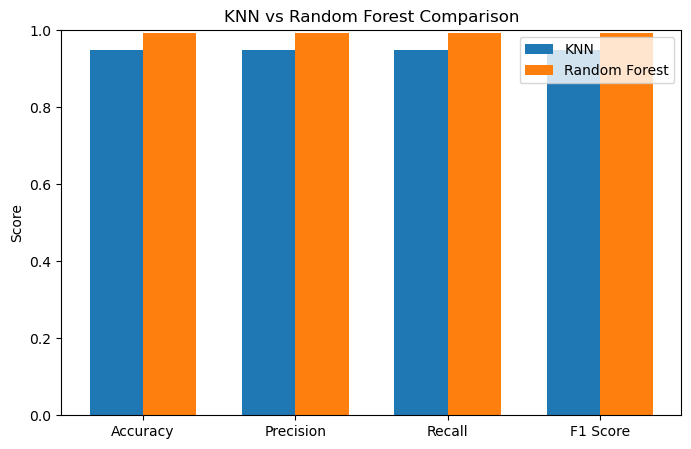

In [14]:
import numpy as np
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

knn_scores = [knn_acc, knn_precision, knn_recall, knn_f1]
rf_scores = [rf_acc, rf_precision, rf_recall, rf_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, knn_scores, width, label="KNN")
plt.bar(x + width/2, rf_scores, width, label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("KNN vs Random Forest Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

